In [1]:
from sklearn.datasets import fetch_california_housing
datasets = fetch_california_housing()

In [2]:
X = datasets.data
Y = datasets.target

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
pip install -q lightbgm

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement lightbgm (from versions: none)
ERROR: No matching distribution found for lightbgm

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import lightgbm as lgb
train_data = lgb.Dataset(X_train, label=Y_train)
test_data = lgb.Dataset(X_test, label=Y_test, reference=train_data)

In [10]:
params = {
    'objective': 'regression',
    'metric': 'mse',
    'verbose': -1
}

In [11]:
model = lgb.train(params, train_data, num_boost_round=20, valid_sets=[test_data])

In [12]:
Y_Pred = model.predict(X_test)

In [13]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y_test, Y_Pred)
mse = mean_squared_error(Y_test, Y_Pred)
print(f'R2 Score (Accuracy): {r2:.4f}')
print(f'MSE (Loss): {mse:.4f}')

R2 Score (Accuracy): 0.7391
MSE (Loss): 0.3419


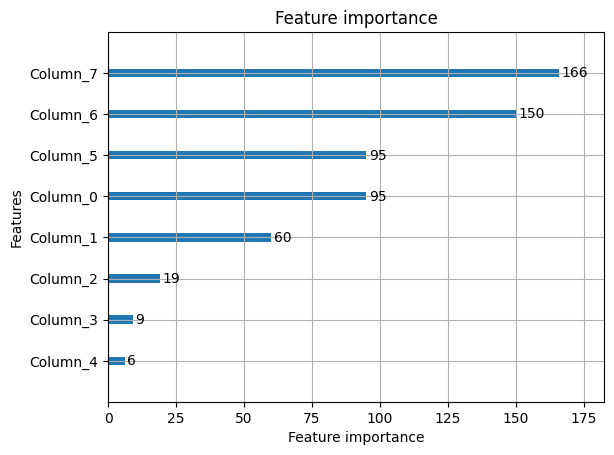

In [14]:
import matplotlib.pyplot as plt
lgb.plot_importance(model)
plt.show()